# Stage 7 – Model Optimization and Final Model Selection

## 1. Introduction

Stage 6 evaluated four baseline machine learning algorithms: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest.

The baseline experiments showed that the models have different strengths and weaknesses. Random Forest demonstrated strong overall performance across several evaluation metrics, while Decision Tree achieved relatively strong recall for identifying employees who left the company.

The purpose of Stage 7 is to investigate whether model performance can be improved through hyperparameter tuning and other modelling choices.

Hyperparameter optimization is performed using the training data with stratified cross-validation. The test dataset is kept separate from the tuning process so that it can later provide an independent evaluation of the optimized models.

The main objectives of this stage are:

- Tune suitable machine learning models.
- Use an appropriate hyperparameter search strategy.
- Compare tuned models with their baseline versions.
- Investigate whether additional modelling choices improve performance.
- Evaluate optimized candidate models.
- Select and justify the final employee attrition prediction model.

## 2. Environment Setup and Library Imports

The required Python libraries are imported for data handling, model development, hyperparameter optimization, cross-validation, evaluation, and visualization.

The same random state used during model development is maintained where applicable to improve reproducibility.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model selection and optimization
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Processed Training and Testing Data

The processed datasets created during the preprocessing and feature engineering stage are loaded directly for model optimization.

Two versions of the feature datasets are available:

- **Scaled data** – suitable for models that are sensitive to feature magnitude, such as Logistic Regression.
- **Unscaled data** – suitable for tree-based models such as Decision Tree and Random Forest.

The same train-test split created during preprocessing is retained to ensure consistency with the baseline experiments performed in Stage 6.

In [2]:
# Path to processed datasets
DATA_PATH = "../processed_data/"

# Load unscaled datasets
X_train_unscaled = pd.read_csv(DATA_PATH + "X_train_unscaled.csv")
X_test_unscaled = pd.read_csv(DATA_PATH + "X_test_unscaled.csv")

# Load scaled datasets
X_train_scaled = pd.read_csv(DATA_PATH + "X_train_scaled.csv")
X_test_scaled = pd.read_csv(DATA_PATH + "X_test_scaled.csv")

# Load target datasets
y_train = pd.read_csv(
    DATA_PATH + "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH + "y_test.csv"
).squeeze("columns")

print("Datasets loaded successfully.\n")

print("Dataset Shapes:")
print("X_train_unscaled :", X_train_unscaled.shape)
print("X_test_unscaled  :", X_test_unscaled.shape)
print("X_train_scaled   :", X_train_scaled.shape)
print("X_test_scaled    :", X_test_scaled.shape)
print("y_train          :", y_train.shape)
print("y_test           :", y_test.shape)

Datasets loaded successfully.

Dataset Shapes:
X_train_unscaled : (4000, 41)
X_test_unscaled  : (1000, 41)
X_train_scaled   : (4000, 41)
X_test_scaled    : (1000, 41)
y_train          : (4000,)
y_test           : (1000,)


### 3.1 Ensure Numerical Feature Representation

Some one-hot encoded categorical features are stored using Boolean (`True`/`False`) values.

For consistent compatibility with model training, validation, and numerical operations, Boolean columns are converted to integer values where `False = 0` and `True = 1`.

This conversion does not change the meaning of the encoded features.

In [3]:
# Convert Boolean columns to integers in all feature datasets
for dataset in [
    X_train_unscaled,
    X_test_unscaled,
    X_train_scaled,
    X_test_scaled
]:
    bool_columns = dataset.select_dtypes(include="bool").columns
    dataset[bool_columns] = dataset[bool_columns].astype(int)

print("Boolean columns converted successfully.")

print("\nRemaining non-numeric columns:")
print(
    X_train_unscaled.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

Boolean columns converted successfully.

Remaining non-numeric columns:
[]


## 4. Optimization and Validation Strategy

Stratified 5-fold cross-validation is used during hyperparameter optimization.

Stratification preserves approximately the same proportion of attrition and non-attrition cases in each validation fold. This is appropriate because the target variable is not perfectly balanced.

Hyperparameters are selected using only the training dataset. The test dataset is not used during hyperparameter selection and is reserved for later evaluation of the optimized models.

Multiple performance metrics will continue to be considered, including accuracy, precision, recall, F1-score and ROC-AUC.

In [4]:
# Stratified 5-fold cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics used for model evaluation
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Stratified 5-fold cross-validation configured.")

Stratified 5-fold cross-validation configured.


## 5. Decision Tree Hyperparameter Optimization

The baseline Decision Tree showed relatively strong recall for identifying employees who left the company, but its precision and overall discrimination were lower than Random Forest.

An unrestricted Decision Tree can grow very deep and learn patterns that are specific to the training data. This may increase the risk of overfitting.

Hyperparameter tuning is therefore performed to control the complexity of the tree and investigate whether its generalization performance can be improved.

Grid Search with stratified 5-fold cross-validation is used because the selected Decision Tree hyperparameters form a manageable search space. The search evaluates different combinations systematically using only the training data.

F1-score is used as the primary optimization metric because employee attrition prediction requires consideration of both precision and recall.

### 5.1 Hyperparameter Search Space

The following Decision Tree hyperparameters are investigated:

- `criterion` – determines the measure used to evaluate feature splits.
- `max_depth` – controls the maximum depth of the tree.
- `min_samples_split` – controls the minimum number of observations required to split a node.
- `min_samples_leaf` – controls the minimum number of observations allowed in a leaf node.

Several values are evaluated for each parameter to investigate the balance between model complexity and generalization.

In [5]:
# Decision Tree hyperparameter search space
decision_tree_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

# Calculate number of combinations
total_combinations = (
    len(decision_tree_param_grid["criterion"])
    * len(decision_tree_param_grid["max_depth"])
    * len(decision_tree_param_grid["min_samples_split"])
    * len(decision_tree_param_grid["min_samples_leaf"])
)

print("Total hyperparameter combinations:", total_combinations)
print("Total fits with 5-fold CV:", total_combinations * 5)

Total hyperparameter combinations: 120
Total fits with 5-fold CV: 600


### 5.2 Grid Search with Cross-Validation

`GridSearchCV` is used to systematically evaluate every specified Decision Tree hyperparameter combination.

Each configuration is evaluated using stratified 5-fold cross-validation on the training dataset. F1-score is used as the primary optimization objective.

The test dataset is not involved in this search.

In [6]:
# Create Decision Tree model
dt_for_tuning = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Configure Grid Search
decision_tree_grid_search = GridSearchCV(
    estimator=dt_for_tuning,
    param_grid=decision_tree_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Run hyperparameter search using training data only
decision_tree_grid_search.fit(
    X_train_unscaled,
    y_train
)

print("\nDecision Tree tuning completed.")

print("\nBest Hyperparameters:")
print(decision_tree_grid_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(decision_tree_grid_search.best_score_, 4)
)

Fitting 5 folds for each of 120 candidates, totalling 600 fits

Decision Tree tuning completed.

Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}

Best Cross-Validation F1: 0.6874


### 5.3 Decision Tree Tuning Results

Grid Search evaluated 120 Decision Tree hyperparameter combinations using stratified 5-fold cross-validation, resulting in 600 cross-validation fits.

The best configuration was:

- **Criterion:** Entropy
- **Maximum depth:** 5
- **Minimum samples split:** 10
- **Minimum samples leaf:** 1

The optimized configuration achieved a best cross-validation F1-score of **0.6874**, compared with approximately **0.5577** for the baseline Decision Tree.

This represents a substantial improvement in cross-validation F1-score. The selected maximum depth of 5 and minimum samples split of 10 restrict the complexity of the tree compared with the unrestricted baseline model. This suggests that controlling tree growth improves its ability to generalize under the selected F1 optimization objective.

However, the best cross-validation F1-score alone is not sufficient for final model selection. The tuned model will also be evaluated across the other performance metrics and later compared with the other optimized models.

### 5.4 Training and Validation Performance of the Selected Decision Tree

To further investigate the effect of hyperparameter tuning, the mean training and validation F1-scores of the best Decision Tree configuration are compared.

A very large difference between training and validation performance can indicate overfitting, where the model performs substantially better on training data than on unseen validation data.

In [7]:
# Get the index of the best Decision Tree configuration
best_dt_index = decision_tree_grid_search.best_index_

# Extract training and validation F1 for the best configuration
best_dt_train_f1 = decision_tree_grid_search.cv_results_[
    "mean_train_score"
][best_dt_index]

best_dt_validation_f1 = decision_tree_grid_search.cv_results_[
    "mean_test_score"
][best_dt_index]

dt_f1_gap = best_dt_train_f1 - best_dt_validation_f1

print("Selected Decision Tree - Training vs Validation\n")
print(f"Mean Training F1   : {best_dt_train_f1:.4f}")
print(f"Mean Validation F1 : {best_dt_validation_f1:.4f}")
print(f"Difference         : {dt_f1_gap:.4f}")

Selected Decision Tree - Training vs Validation

Mean Training F1   : 0.7007
Mean Validation F1 : 0.6874
Difference         : 0.0133


### 5.5 Optimized Decision Tree Cross-Validation Evaluation

Although F1-score was used as the primary optimization objective, the selected Decision Tree is also evaluated using accuracy, precision, recall and ROC-AUC.

This provides a more complete assessment of whether the improvement in F1-score is accompanied by reasonable performance across the other evaluation measures.

In [8]:
# Retrieve the best tuned Decision Tree
tuned_decision_tree = decision_tree_grid_search.best_estimator_

# Evaluate tuned model using the same cross-validation strategy
tuned_dt_cv_results = cross_validate(
    tuned_decision_tree,
    X_train_unscaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Tuned Decision Tree - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = tuned_dt_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned Decision Tree - 5-Fold Cross-Validation Results

Accuracy  : 0.8010 ± 0.0099
Precision : 0.8228 ± 0.0108
Recall    : 0.5909 ± 0.0310
F1        : 0.6874 ± 0.0218
Roc_auc   : 0.7552 ± 0.0193


### 5.6 Decision Tree Optimization Observation

Hyperparameter tuning substantially improved the Decision Tree's cross-validation performance.

The baseline Decision Tree achieved an F1-score of approximately 0.558, while the optimized Decision Tree achieved approximately 0.687. Accuracy increased from approximately 0.668 to 0.801, precision increased from approximately 0.551 to 0.823, recall increased from approximately 0.565 to 0.591, and ROC-AUC increased from approximately 0.647 to 0.755.

The selected model used entropy as the splitting criterion, a maximum depth of 5, a minimum of 10 samples required to split a node, and a minimum leaf size of 1.

The mean training F1-score was 0.7007, while the mean validation F1-score was 0.6874, producing a relatively small difference of 0.0133. Therefore, the selected configuration does not show a strong indication of severe overfitting based on the training-validation F1 comparison.

Overall, controlling the complexity of the Decision Tree substantially improved its cross-validation performance compared with the unrestricted baseline model.

### 5.7 Baseline vs Optimized Decision Tree

The baseline and optimized Decision Tree models are compared using the same cross-validation metrics. This comparison demonstrates the effect of hyperparameter tuning on model performance.

,Baseline Decision Tree,Tuned Decision Tree
Accuracy,0.6675,0.8010
Precision,0.5510,0.8228
Recall,0.5654,0.5909
F1,0.5577,0.6874
ROC-AUC,0.6466,0.7552


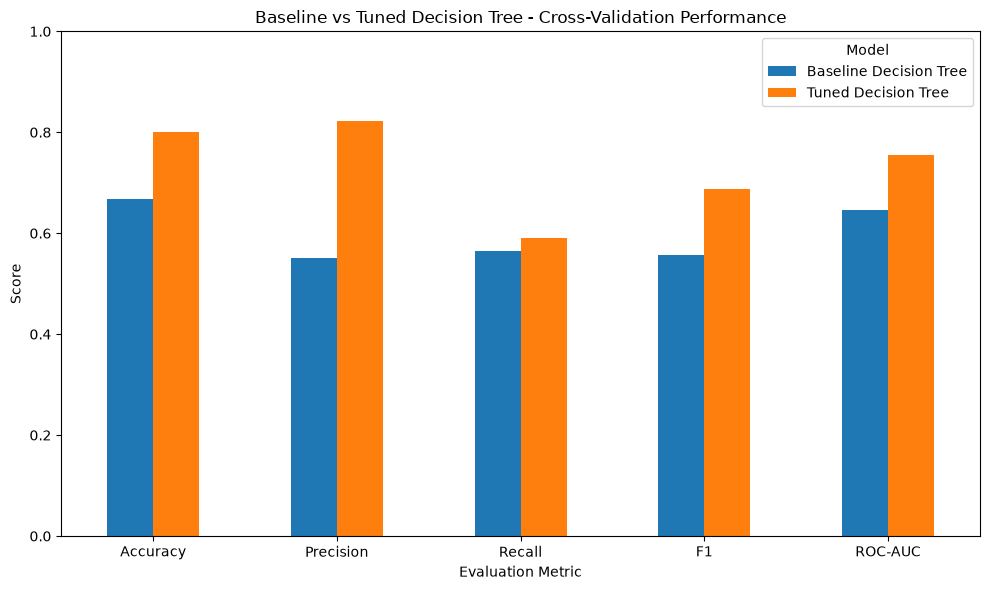

In [9]:
# Baseline Decision Tree cross-validation results from Stage 6
baseline_dt_metrics = {
    "Accuracy": 0.6675,
    "Precision": 0.5510,
    "Recall": 0.5654,
    "F1": 0.5577,
    "ROC-AUC": 0.6466
}

# Tuned Decision Tree results
tuned_dt_metrics = {
    "Accuracy": tuned_dt_cv_results["test_accuracy"].mean(),
    "Precision": tuned_dt_cv_results["test_precision"].mean(),
    "Recall": tuned_dt_cv_results["test_recall"].mean(),
    "F1": tuned_dt_cv_results["test_f1"].mean(),
    "ROC-AUC": tuned_dt_cv_results["test_roc_auc"].mean()
}

# Create comparison DataFrame
dt_comparison = pd.DataFrame({
    "Baseline Decision Tree": baseline_dt_metrics,
    "Tuned Decision Tree": tuned_dt_metrics
})

display(dt_comparison.round(4))

# Plot comparison
ax = dt_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Decision Tree - Cross-Validation Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 6. Random Forest Hyperparameter Optimization

Random Forest demonstrated the strongest overall performance among the baseline models in Stage 6. It achieved high accuracy, precision, F1-score and ROC-AUC while maintaining reasonable recall.

Random Forest combines predictions from multiple Decision Trees, which generally improves stability and reduces the risk of overfitting compared with a single unrestricted tree.

However, the performance of Random Forest depends on several hyperparameters controlling the number, complexity and diversity of trees. Therefore, hyperparameter optimization is performed to investigate whether its performance can be improved further.

Randomized Search with stratified 5-fold cross-validation is used because the Random Forest search space contains many possible hyperparameter combinations. F1-score is used as the primary optimization metric to balance precision and recall.

### 6.1 Random Forest Hyperparameter Search Space

The Random Forest optimization investigates hyperparameters that control the number of trees, individual tree complexity and feature sampling.

The selected hyperparameters are:

- `n_estimators` – number of trees in the forest.
- `max_depth` – maximum depth of each tree.
- `min_samples_split` – minimum samples required to split a node.
- `min_samples_leaf` – minimum samples required in a leaf.
- `max_features` – number of features considered when identifying a split.

A randomized search is used instead of exhaustively evaluating every possible combination because the Random Forest search space is considerably larger than the Decision Tree search space.

In [10]:
random_forest_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

total_rf_combinations = (
    len(random_forest_param_dist["n_estimators"])
    * len(random_forest_param_dist["max_depth"])
    * len(random_forest_param_dist["min_samples_split"])
    * len(random_forest_param_dist["min_samples_leaf"])
    * len(random_forest_param_dist["max_features"])
)

print("Total possible Random Forest combinations:", total_rf_combinations)

Total possible Random Forest combinations: 960


### 6.2 Randomized Search with Cross-Validation

`RandomizedSearchCV` is used to sample a fixed number of Random Forest hyperparameter combinations from the larger search space.

Each sampled configuration is evaluated using stratified 5-fold cross-validation on the training dataset. This provides a practical balance between computational cost and exploration of different model configurations.

The optimization objective remains F1-score so that both precision and recall are considered during hyperparameter selection.

In [11]:
# Create baseline Random Forest estimator for tuning
rf_for_tuning = RandomForestClassifier(
    random_state=RANDOM_STATE
)

# Configure Randomized Search
random_forest_random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=random_forest_param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Run optimization using training data only
random_forest_random_search.fit(
    X_train_unscaled,
    y_train
)

print("\nRandom Forest tuning completed.")

print("\nBest Hyperparameters:")
print(random_forest_random_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(random_forest_random_search.best_score_, 4)
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Random Forest tuning completed.

Best Hyperparameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}

Best Cross-Validation F1: 0.6947


### 6.3 Training and Validation Performance of the Selected Random Forest

The training and validation F1-scores of the selected Random Forest configuration are compared to check the generalization behaviour of the optimized model.

In [12]:
# Get index of best Random Forest configuration
best_rf_index = random_forest_random_search.best_index_

# Training and validation F1
best_rf_train_f1 = random_forest_random_search.cv_results_[
    "mean_train_score"
][best_rf_index]

best_rf_validation_f1 = random_forest_random_search.cv_results_[
    "mean_test_score"
][best_rf_index]

rf_f1_gap = best_rf_train_f1 - best_rf_validation_f1

print("Selected Random Forest - Training vs Validation\n")
print(f"Mean Training F1   : {best_rf_train_f1:.4f}")
print(f"Mean Validation F1 : {best_rf_validation_f1:.4f}")
print(f"Difference         : {rf_f1_gap:.4f}")

Selected Random Forest - Training vs Validation

Mean Training F1   : 0.8290
Mean Validation F1 : 0.6947
Difference         : 0.1344


### 6.4 Optimized Random Forest Cross-Validation Evaluation

The optimized Random Forest is evaluated using accuracy, precision, recall, F1-score and ROC-AUC with the same stratified 5-fold cross-validation strategy used for the baseline models.

In [13]:
# Best tuned Random Forest
tuned_random_forest = random_forest_random_search.best_estimator_

# Evaluate using 5-fold cross-validation
tuned_rf_cv_results = cross_validate(
    tuned_random_forest,
    X_train_unscaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Tuned Random Forest - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = tuned_rf_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned Random Forest - 5-Fold Cross-Validation Results

Accuracy  : 0.8053 ± 0.0084
Precision : 0.8296 ± 0.0134
Recall    : 0.5984 ± 0.0311
F1        : 0.6947 ± 0.0198
Roc_auc   : 0.7588 ± 0.0180


### 6.5 Baseline vs Optimized Random Forest

The cross-validation performance of the optimized Random Forest is compared with the baseline Random Forest to determine the effect of hyperparameter tuning.

,Baseline Random Forest,Tuned Random Forest
Accuracy,0.7963,0.8052
Precision,0.8167,0.8296
Recall,0.5822,0.5984
F1,0.6790,0.6947
ROC-AUC,0.7612,0.7588


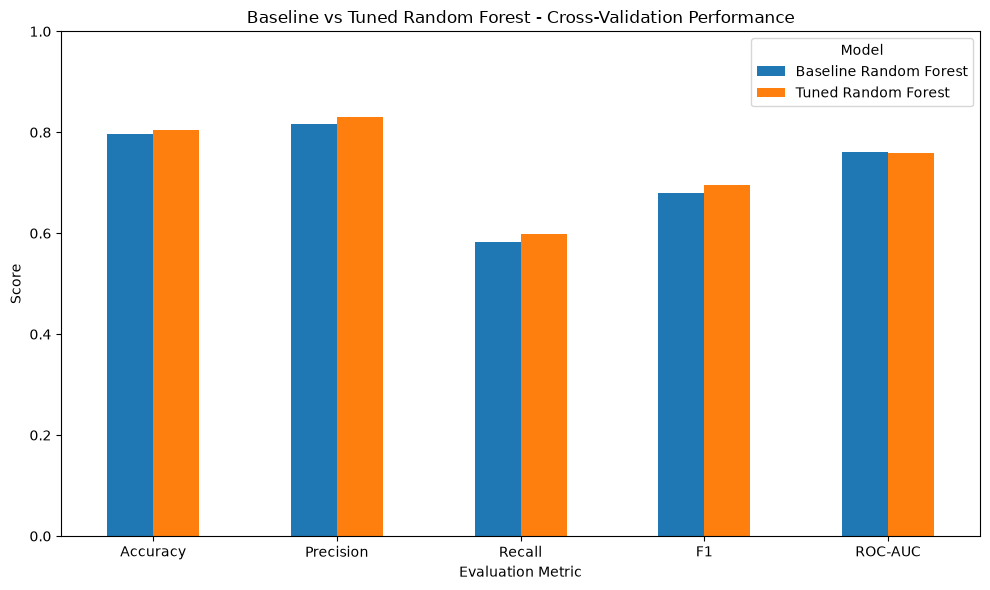

In [14]:
# Baseline Random Forest results from Stage 6
baseline_rf_metrics = {
    "Accuracy": 0.7963,
    "Precision": 0.8167,
    "Recall": 0.5822,
    "F1": 0.6790,
    "ROC-AUC": 0.7612
}

# Tuned Random Forest results
tuned_rf_metrics = {
    "Accuracy": tuned_rf_cv_results["test_accuracy"].mean(),
    "Precision": tuned_rf_cv_results["test_precision"].mean(),
    "Recall": tuned_rf_cv_results["test_recall"].mean(),
    "F1": tuned_rf_cv_results["test_f1"].mean(),
    "ROC-AUC": tuned_rf_cv_results["test_roc_auc"].mean()
}

rf_comparison = pd.DataFrame({
    "Baseline Random Forest": baseline_rf_metrics,
    "Tuned Random Forest": tuned_rf_metrics
})

display(rf_comparison.round(4))

# Plot comparison
rf_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Random Forest - Cross-Validation Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 7. Logistic Regression Hyperparameter Optimization

Logistic Regression is optimized to determine whether adjusting its regularization settings and class weighting can improve performance compared with the baseline model.

Grid Search with stratified 5-fold cross-validation is used because the selected hyperparameter search space is relatively small and manageable.

F1-score is again used as the primary optimization metric to maintain consistency with the Decision Tree and Random Forest optimization experiments.

### 7.1 Logistic Regression Hyperparameter Search Space

The optimization investigates the regularization strength, regularization type and class weighting of Logistic Regression.

The following hyperparameters are evaluated:

- `C` – controls regularization strength.
- `penalty` – determines the type of regularization applied.
- `class_weight` – determines whether additional importance is given to the minority class.

The `liblinear` solver is used because it supports both L1 and L2 regularization for binary classification.

In [15]:
# Logistic Regression hyperparameter search space
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]
}

total_lr_combinations = (
    len(logistic_param_grid["C"])
    * len(logistic_param_grid["penalty"])
    * len(logistic_param_grid["class_weight"])
)

print("Total Logistic Regression combinations:", total_lr_combinations)
print("Total fits with 5-fold CV:", total_lr_combinations * 5)

Total Logistic Regression combinations: 20
Total fits with 5-fold CV: 100


### 7.2 Grid Search with Cross-Validation

Grid Search is used to systematically evaluate the selected Logistic Regression hyperparameter combinations.

Each configuration is evaluated using stratified 5-fold cross-validation on the scaled training dataset. The configuration with the highest mean F1-score is selected.

In [16]:
# Create Logistic Regression model
lr_for_tuning = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Configure Grid Search
logistic_grid_search = GridSearchCV(
    estimator=lr_for_tuning,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Use SCALED training data
logistic_grid_search.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression tuning completed.")

print("\nBest Hyperparameters:")
print(logistic_grid_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(logistic_grid_search.best_score_, 4)
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Logistic Regression tuning completed.

Best Hyperparameters:
{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1'}

Best Cross-Validation F1: 0.5785


c:\Users\pesha\OneDrive\Desktop\New folder\FDM\hr-attrition-it3051\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\pesha\OneDrive\Desktop\New folder\FDM\hr-attrition-it3051\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### 7.3 Training and Validation Performance

The mean training and validation F1-scores of the selected Logistic Regression configuration are compared to examine its generalization behaviour.

In [17]:
best_lr_index = logistic_grid_search.best_index_

best_lr_train_f1 = logistic_grid_search.cv_results_[
    "mean_train_score"
][best_lr_index]

best_lr_validation_f1 = logistic_grid_search.cv_results_[
    "mean_test_score"
][best_lr_index]

lr_f1_gap = best_lr_train_f1 - best_lr_validation_f1

print("Selected Logistic Regression - Training vs Validation\n")

print(f"Mean Training F1   : {best_lr_train_f1:.4f}")
print(f"Mean Validation F1 : {best_lr_validation_f1:.4f}")
print(f"Difference         : {lr_f1_gap:.4f}")

Selected Logistic Regression - Training vs Validation

Mean Training F1   : 0.5870
Mean Validation F1 : 0.5785
Difference         : 0.0085


### 7.4 Optimized Logistic Regression Cross-Validation Evaluation

The optimized Logistic Regression model is evaluated using the same five performance metrics used throughout model development and optimization.

In [18]:
tuned_logistic_regression = logistic_grid_search.best_estimator_

tuned_lr_cv_results = cross_validate(
    tuned_logistic_regression,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Tuned Logistic Regression - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = tuned_lr_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Tuned Logistic Regression - 5-Fold Cross-Validation Results

Accuracy  : 0.6483 ± 0.0085
Precision : 0.5205 ± 0.0087
Recall    : 0.6516 ± 0.0354
F1        : 0.5785 ± 0.0188
Roc_auc   : 0.7092 ± 0.0109


### 7.5 Baseline vs Optimized Logistic Regression

The optimized Logistic Regression model is compared with its baseline version to determine the effect of hyperparameter tuning.

,Baseline Logistic Regression,Tuned Logistic Regression
Accuracy,0.6995,0.6483
Precision,0.6414,0.5205
Recall,0.4319,0.6516
F1,0.5159,0.5785
ROC-AUC,0.7031,0.7092


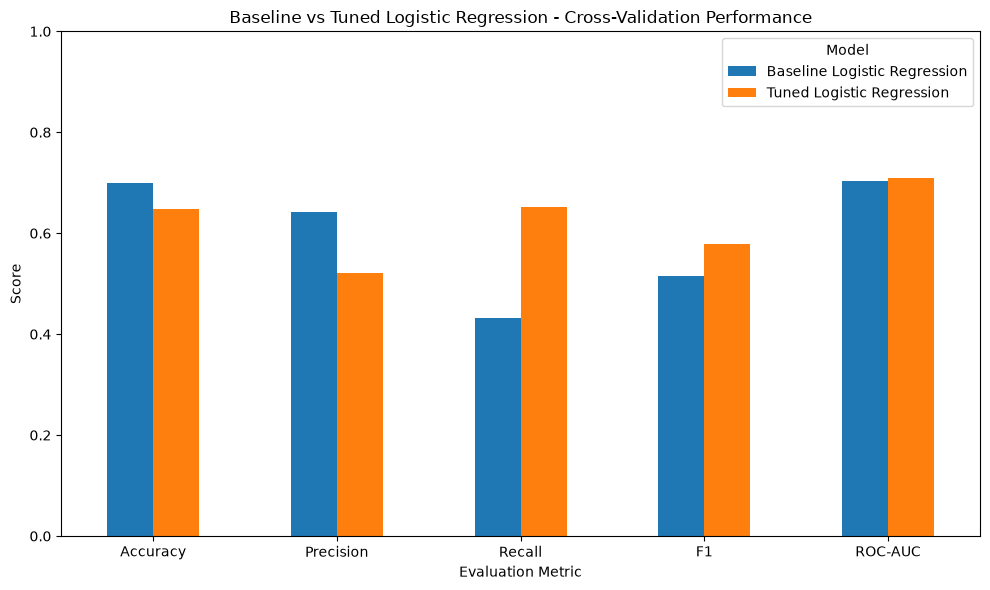

In [19]:
# Stage 6 baseline Logistic Regression results
baseline_lr_metrics = {
    "Accuracy": 0.6995,
    "Precision": 0.6414,
    "Recall": 0.4319,
    "F1": 0.5159,
    "ROC-AUC": 0.7031
}

# Tuned results
tuned_lr_metrics = {
    "Accuracy": tuned_lr_cv_results["test_accuracy"].mean(),
    "Precision": tuned_lr_cv_results["test_precision"].mean(),
    "Recall": tuned_lr_cv_results["test_recall"].mean(),
    "F1": tuned_lr_cv_results["test_f1"].mean(),
    "ROC-AUC": tuned_lr_cv_results["test_roc_auc"].mean()
}

lr_comparison = pd.DataFrame({
    "Baseline Logistic Regression": baseline_lr_metrics,
    "Tuned Logistic Regression": tuned_lr_metrics
})

display(lr_comparison.round(4))

lr_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Baseline vs Tuned Logistic Regression - Cross-Validation Performance"
)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 8. Feature Selection Experiment

In addition to hyperparameter tuning, a feature selection experiment is performed to investigate whether reducing the number of input features can improve model performance.

Random Forest feature importance is used to rank the available features. The most important features are then selected and an optimized Random Forest is evaluated using the reduced feature set.

This experiment helps determine whether a simpler feature representation can maintain or improve predictive performance while reducing unnecessary input variables.

In [20]:
# Extract feature importance from the tuned Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train_unscaled.columns,
    "Importance": tuned_random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
0,AppraisalRating,0.164624
1,DoesOvertime,0.114065
2,JobSatisfaction,0.108834
3,WorkLifeBalance,0.078048
4,MonthlySalary,0.061709
5,DistanceFromHome,0.056064
6,LeavesTaken,0.047260
7,TrainingPerYear,0.042799
8,Age,0.040707
9,TrainingHours,0.037801


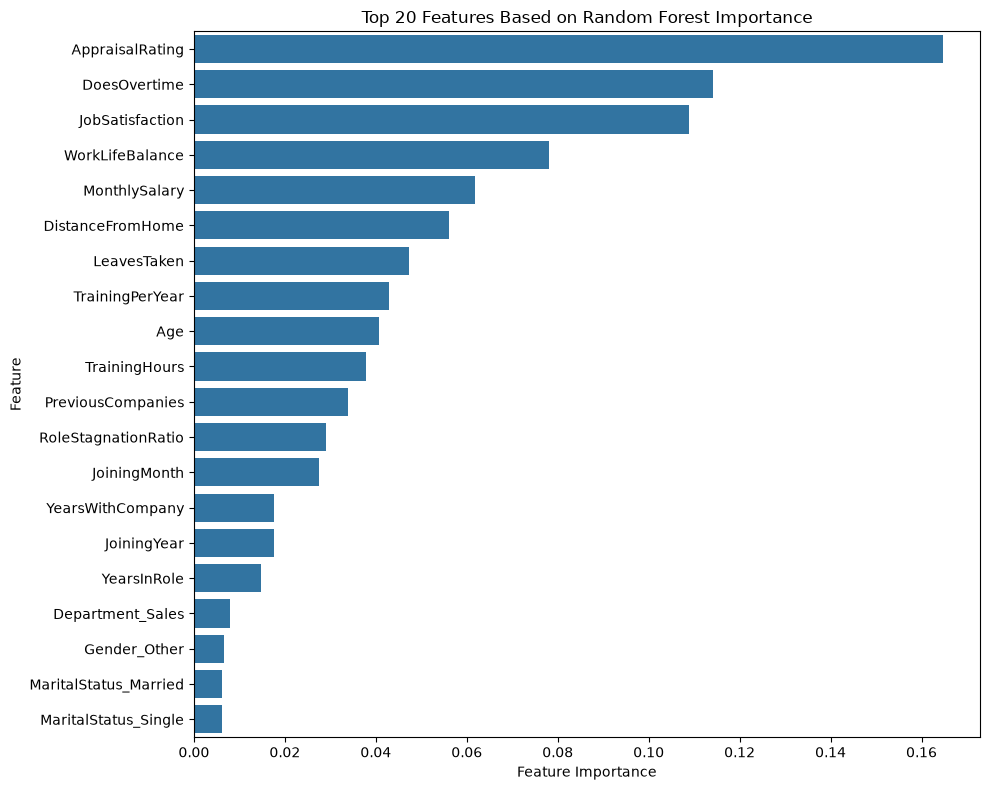

In [21]:
# Plot top 20 most important features
top_20_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features Based on Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 8.1 Evaluation of Different Feature Set Sizes

Several subsets of the highest-ranked features are evaluated to determine whether reducing the feature space affects model performance.

The experiment evaluates the top 10, 15, 20, 25, 30 and all available features. The same optimized Random Forest configuration and stratified 5-fold cross-validation strategy are used for each feature subset.

F1-score and ROC-AUC are recorded for comparison.

In [22]:
# Different feature set sizes
feature_counts = [10, 15, 20, 25, 30, X_train_unscaled.shape[1]]

feature_selection_results = []

for n_features in feature_counts:

    selected_features = feature_importance.head(
        n_features
    )["Feature"].tolist()

    X_selected = X_train_unscaled[selected_features]

    scores = cross_validate(
        tuned_random_forest,
        X_selected,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    feature_selection_results.append({
        "Number of Features": n_features,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

feature_selection_results = pd.DataFrame(
    feature_selection_results
)

display(feature_selection_results.round(4))

,Number of Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,10,0.7955,0.8179,0.5775,0.6765,0.7541
1,15,0.8040,0.8274,0.5963,0.6926,0.7578
2,20,0.8038,0.8266,0.5963,0.6924,0.7620
3,25,0.8050,0.8287,0.5984,0.6944,0.7593
4,30,0.8052,0.8289,0.5990,0.6949,0.7594
5,41,0.8050,0.8293,0.5977,0.6942,0.7591


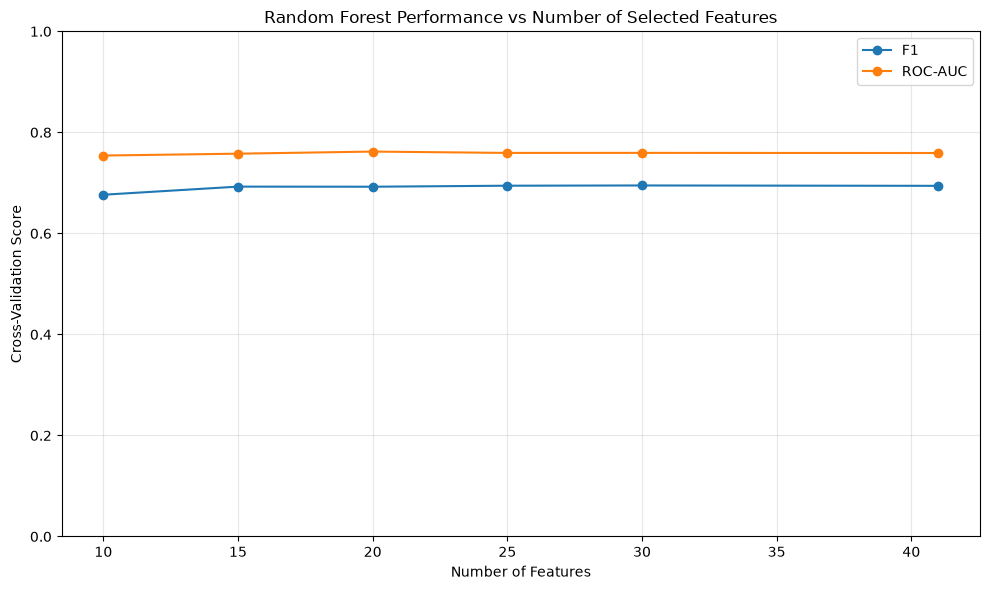

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    feature_selection_results["Number of Features"],
    feature_selection_results["F1"],
    marker="o",
    label="F1"
)

plt.plot(
    feature_selection_results["Number of Features"],
    feature_selection_results["ROC-AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.title("Random Forest Performance vs Number of Selected Features")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 Selected Feature Subset

The feature selection experiment showed that using the top 30 features produced the highest cross-validation F1-score of 0.6949.

Therefore, the top 30 features are selected for the feature-selected Random Forest model. This reduces the feature set from 41 to 30 while maintaining strong predictive performance.

In [24]:
# Select the top 30 features
selected_feature_count = 30

selected_features = feature_importance.head(
    selected_feature_count
)["Feature"].tolist()

print("Number of selected features:", len(selected_features))

print("\nSelected Features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

Number of selected features: 30

Selected Features:
1. AppraisalRating
2. DoesOvertime
3. JobSatisfaction
4. WorkLifeBalance
5. MonthlySalary
6. DistanceFromHome
7. LeavesTaken
8. TrainingPerYear
9. Age
10. TrainingHours
11. PreviousCompanies
12. RoleStagnationRatio
13. JoiningMonth
14. YearsWithCompany
15. JoiningYear
16. YearsInRole
17. Department_Sales
18. Gender_Other
19. MaritalStatus_Married
20. MaritalStatus_Single
21. Gender_Male
22. Department_HR
23. Designation_Software Engineer
24. Designation_Office Assistant
25. City_Kolkata
26. EducationQualification_BA
27. EducationQualification_Diploma
28. EducationQualification_MBA
29. Designation_Sales Associate
30. Designation_HR Executive


### 8.3 Feature-Selected Random Forest

The optimized Random Forest is evaluated again using only the selected top 30 features.

The same stratified 5-fold cross-validation strategy and evaluation metrics are retained to ensure a fair comparison with the previous experiments.

In [25]:
# Create reduced training dataset
X_train_selected = X_train_unscaled[selected_features]

# Evaluate tuned Random Forest using selected features
selected_rf_cv_results = cross_validate(
    tuned_random_forest,
    X_train_selected,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("Feature-Selected Random Forest - 5-Fold CV Results\n")

for metric in scoring_metrics:
    scores = selected_rf_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Feature-Selected Random Forest - 5-Fold CV Results

Accuracy  : 0.8053 ± 0.0090
Precision : 0.8289 ± 0.0141
Recall    : 0.5990 ± 0.0314
F1        : 0.6949 ± 0.0204
Roc_auc   : 0.7594 ± 0.0164


## 9. Optimized Model Comparison

The optimized models are compared using the same stratified 5-fold cross-validation strategy.

The comparison includes the tuned Logistic Regression, tuned Decision Tree, tuned Random Forest, and feature-selected Random Forest.

F1-score is treated as the primary model-selection metric, while accuracy, precision, recall and ROC-AUC are also considered.

In [26]:
final_cv_comparison = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Random Forest - Top 30 Features"
    ],

    "Accuracy": [
        tuned_lr_cv_results["test_accuracy"].mean(),
        tuned_dt_cv_results["test_accuracy"].mean(),
        tuned_rf_cv_results["test_accuracy"].mean(),
        selected_rf_cv_results["test_accuracy"].mean()
    ],

    "Precision": [
        tuned_lr_cv_results["test_precision"].mean(),
        tuned_dt_cv_results["test_precision"].mean(),
        tuned_rf_cv_results["test_precision"].mean(),
        selected_rf_cv_results["test_precision"].mean()
    ],

    "Recall": [
        tuned_lr_cv_results["test_recall"].mean(),
        tuned_dt_cv_results["test_recall"].mean(),
        tuned_rf_cv_results["test_recall"].mean(),
        selected_rf_cv_results["test_recall"].mean()
    ],

    "F1": [
        tuned_lr_cv_results["test_f1"].mean(),
        tuned_dt_cv_results["test_f1"].mean(),
        tuned_rf_cv_results["test_f1"].mean(),
        selected_rf_cv_results["test_f1"].mean()
    ],

    "ROC-AUC": [
        tuned_lr_cv_results["test_roc_auc"].mean(),
        tuned_dt_cv_results["test_roc_auc"].mean(),
        tuned_rf_cv_results["test_roc_auc"].mean(),
        selected_rf_cv_results["test_roc_auc"].mean()
    ]
})

final_cv_comparison = final_cv_comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(final_cv_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest - Top 30 Features,0.8052,0.8289,0.5990,0.6949,0.7594
1,Tuned Random Forest,0.8052,0.8296,0.5984,0.6947,0.7588
2,Tuned Decision Tree,0.8010,0.8228,0.5909,0.6874,0.7552
3,Tuned Logistic Regression,0.6483,0.5205,0.6516,0.5785,0.7092


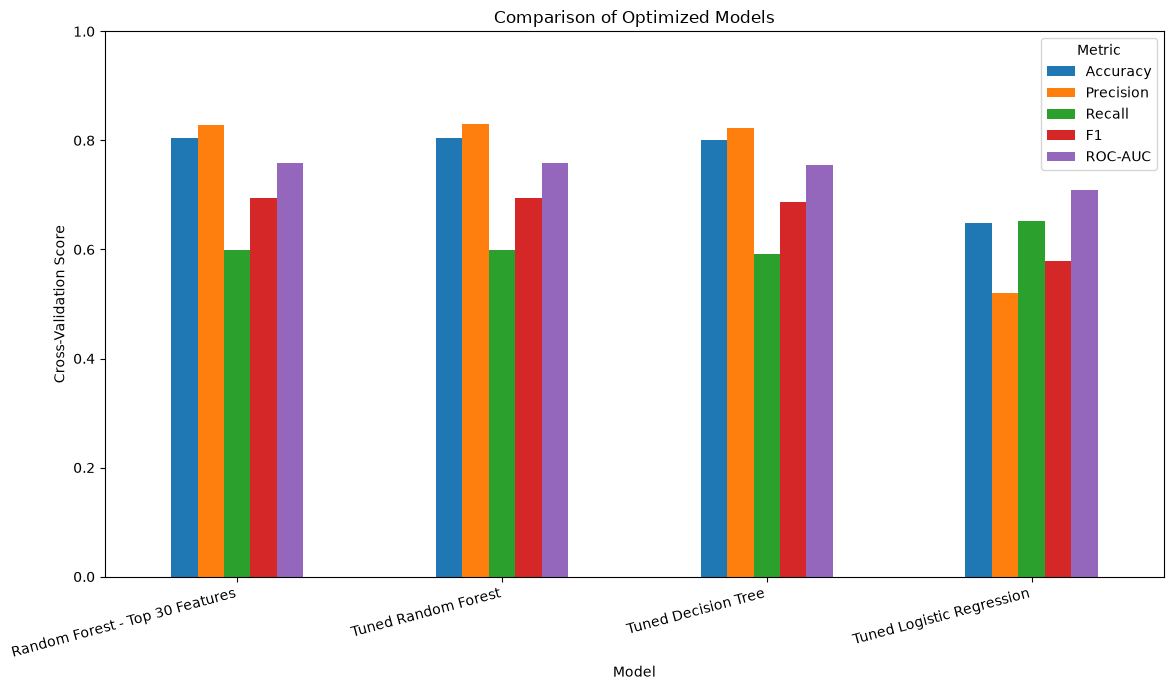

In [27]:
comparison_plot = final_cv_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Optimized Models")
plt.ylabel("Cross-Validation Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 10. Final Model Evaluation

Based on the cross-validation experiments, the optimized Random Forest using the top 30 selected features achieved the highest mean F1-score.

Therefore, this configuration is selected as the final model candidate.

The final model is trained using the complete training dataset with the selected 30 features and evaluated once on the previously untouched test dataset. The test set was not used during hyperparameter tuning or feature selection, allowing it to provide an independent estimate of final model performance.

In [28]:
# Prepare selected training and testing features
X_train_final = X_train_unscaled[selected_features]
X_test_final = X_test_unscaled[selected_features]

print("Final Training Shape:", X_train_final.shape)
print("Final Testing Shape :", X_test_final.shape)

# Train the selected final model
final_model = tuned_random_forest

final_model.fit(
    X_train_final,
    y_train
)

print("\nFinal model trained successfully.")

Final Training Shape: (4000, 30)
Final Testing Shape : (1000, 30)

Final model trained successfully.


### 10.1 Final Test-Set Performance

The trained final model is evaluated on the untouched test dataset using accuracy, precision, recall, F1-score and ROC-AUC.

These metrics provide the final assessment of how well the selected model generalizes to unseen employee records.

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Predictions
y_test_pred = final_model.predict(X_test_final)

# Probability of class 1
y_test_prob = final_model.predict_proba(X_test_final)[:, 1]

# Calculate metrics
final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)
final_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Final Model - Test Set Performance\n")

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1        : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Stay (0)", "Left (1)"]
    )
)

Final Model - Test Set Performance

Accuracy  : 0.7890
Precision : 0.7985
Recall    : 0.5768
F1        : 0.6698
ROC-AUC   : 0.7538

Classification Report:

              precision    recall  f1-score   support

    Stay (0)       0.79      0.91      0.84       629
    Left (1)       0.80      0.58      0.67       371

    accuracy                           0.79      1000
   macro avg       0.79      0.75      0.76      1000
weighted avg       0.79      0.79      0.78      1000



### 10.2 Confusion Matrix

The confusion matrix is used to examine the types of predictions made by the final model. It shows correctly and incorrectly classified employees for both the Stay and Left classes.

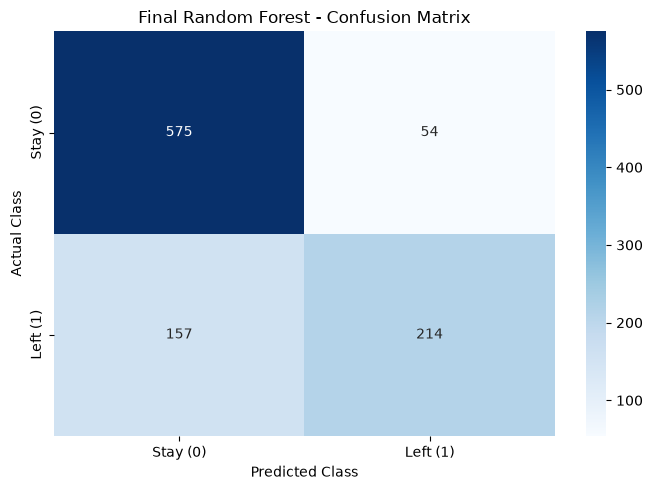

In [30]:
final_cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Left (1)"],
    yticklabels=["Stay (0)", "Left (1)"]
)

plt.title("Final Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### 10.3 ROC Curve

The ROC curve evaluates the ability of the final model to distinguish between employees who stay and employees who leave across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discrimination ability of the model.

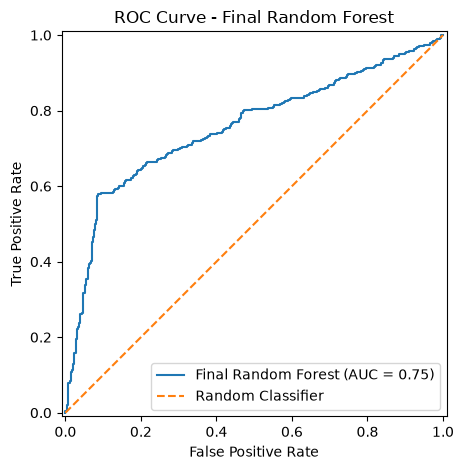

In [31]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    name="Final Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Final Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Cross-Validation and Final Test Performance

The selected Random Forest model achieved the highest F1-score during the cross-validation experiments when using the top 30 features.

The model was then evaluated once on the untouched test dataset. Comparing cross-validation performance with test performance helps determine whether the selected model generalizes reasonably well to previously unseen data.

In [32]:
# Cross-validation performance of selected model
cv_final_metrics = {
    "Accuracy": selected_rf_cv_results["test_accuracy"].mean(),
    "Precision": selected_rf_cv_results["test_precision"].mean(),
    "Recall": selected_rf_cv_results["test_recall"].mean(),
    "F1": selected_rf_cv_results["test_f1"].mean(),
    "ROC-AUC": selected_rf_cv_results["test_roc_auc"].mean()
}

# Final test performance
test_final_metrics = {
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "ROC-AUC": final_roc_auc
}

generalization_comparison = pd.DataFrame({
    "Cross-Validation": cv_final_metrics,
    "Final Test Set": test_final_metrics
})

display(generalization_comparison.round(4))

,Cross-Validation,Final Test Set
Accuracy,0.8052,0.7890
Precision,0.8289,0.7985
Recall,0.5990,0.5768
F1,0.6949,0.6698
ROC-AUC,0.7594,0.7538


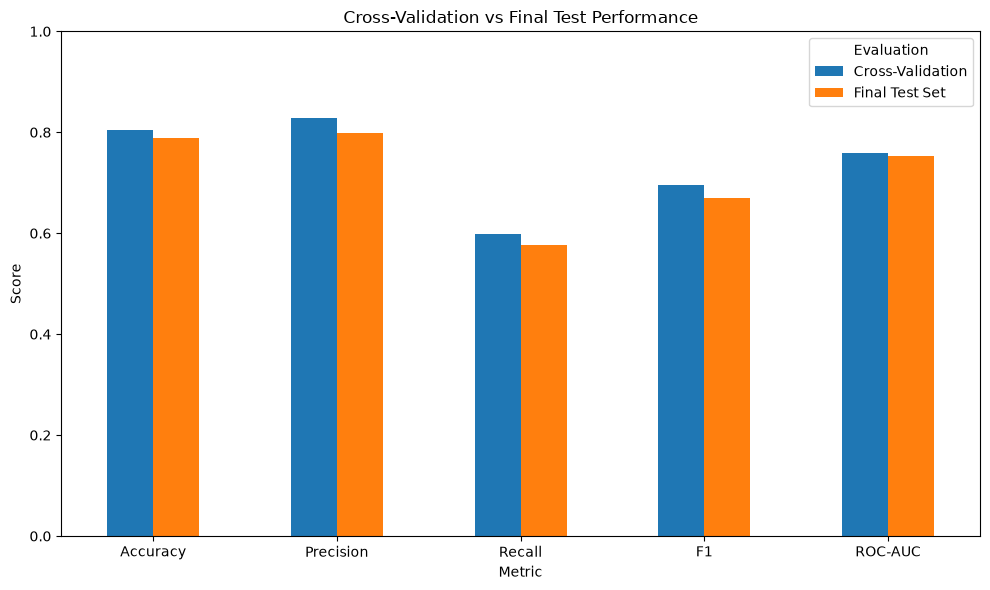

In [33]:
generalization_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cross-Validation vs Final Test Performance")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation")
plt.tight_layout()
plt.show()

## 12. Final Model Selection

The optimized Random Forest using the top 30 selected features was selected as the final model.

During stratified 5-fold cross-validation, this model achieved an accuracy of 0.8052, precision of 0.8289, recall of 0.5990, F1-score of 0.6949, and ROC-AUC of 0.7594.

F1-score was used as the primary model-selection metric because the employee attrition problem requires consideration of both precision and recall for the attrition class. The target distribution is also moderately imbalanced, with approximately 62.9% of employees belonging to the Stay class and 37.1% belonging to the Left class.

The feature-selection experiment showed that using the top 30 features produced an F1-score of 0.6949, compared with 0.6947 for the tuned Random Forest using all features. Although the improvement is small, the reduced model uses 30 instead of 41 features while maintaining comparable predictive performance.

On the untouched test dataset, the final model achieved an accuracy of 0.7890, precision of 0.7985, recall of 0.5768, F1-score of 0.6698, and ROC-AUC of 0.7538.

The test results are reasonably close to the cross-validation results, indicating that the model maintains similar performance on unseen data. Therefore, the optimized Random Forest with the selected top 30 features was retained as the final model.

## 13. Important Observations

Several important observations were obtained during model development and optimization:

1. Random Forest provided the strongest overall performance among the baseline models, particularly in accuracy, precision, F1-score and ROC-AUC.

2. Hyperparameter tuning improved the Random Forest F1-score from approximately 0.6790 to 0.6947.

3. Hyperparameter tuning significantly improved the Decision Tree compared with its baseline version, showing the importance of controlling tree complexity.

4. The tuned Logistic Regression increased recall substantially, but this was accompanied by reductions in accuracy and precision. This demonstrates the trade-off between identifying more employees who leave and producing more false-positive attrition predictions.

5. Feature selection showed that similar Random Forest performance could be obtained using fewer features. The top 30 features achieved the highest F1-score of 0.6949 in the feature-selection experiment.

6. The final model achieved an F1-score of 0.6698 and ROC-AUC of 0.7538 on the untouched test set, which were reasonably close to its cross-validation performance.

7. The final confusion matrix showed 214 correctly identified employees who left the company and 157 employees who left but were incorrectly predicted to stay. Therefore, although the final model performs well overall, there remains room to improve attrition-class recall.

## 14. Saving the Final Model

The selected Random Forest model and its selected feature list are saved so that the same trained model and feature configuration can later be used by other components of the project without retraining.

In [34]:
import joblib
import os

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save final trained model
joblib.dump(
    final_model,
    "../models/final_random_forest_model.pkl"
)

# Save selected feature names
joblib.dump(
    selected_features,
    "../models/selected_features.pkl"
)

print("Final model saved successfully.")
print("Selected feature list saved successfully.")
print("Number of selected features:", len(selected_features))

Final model saved successfully.
Selected feature list saved successfully.
Number of selected features: 30
